## Calculate the Lyapunov spectrum of ECA rule 150

The Jacobian associated with an ECA of $N$ cells governed by rule 150 is
$$
\mathbf{J}(\vec{x}^t) = \mathbf{J} = \begin{pmatrix}
1 & 1 & 0 & \ldots & 0 & 0 & 1 \\
1 & 1 & 1 & \ldots & 0 & 0 & 0 \\
\vdots & \vdots & \vdots & \ddots & \vdots & \vdots & \vdots \\
0 & 0 & 0 & \ldots & 1 & 1 & 1 \\
1 & 0 & 0 & \ldots & 0 & 1 & 1
\end{pmatrix}.
$$
The propagation after $t$ time steps of a sphere of unit perturbations $\mathbf{Y}^0$ is therefore
$$
\mathbf{Y}^t = \mathbf{J}(\vec{x}^{t-1}) \mathbf{J}(\vec{x}^{t-2}) \cdots \mathbf{J}(\vec{x}^{0}) \mathbf{Y}^0 = \mathbf{J}\mathbf{J}\cdots\mathbf{J} = \left(\mathbf{J}\right)^t,
$$
where in the final expression the superscript $t$ is an exponent. Now,
$$
\left(\mathbf{J}^t\right)_{ij} = \sum_{k_1 k_2 ... k_{t-1}}\mathbf{J}_{ik_1} \mathbf{J}_{k_1 k_2} \ldots \mathbf{J}_{k_{t-2} k_{t-1}} \mathbf{J}_{k_{t-1} j},
$$
and $\mathbf{J}$ is $0$ everywhere, except
$$
\mathbf{J}_{ij} = 1 \text{ if } \begin{cases}
|i - j| \leq 1, \text{ or}\\
i = 1 \land j = N, \text{ or}\\
i = N \land j = 1.
\end{cases}
$$
The eigenvalues of $(\mathbf{J})^t$ are easily calculated:
$$
(\mathbf{J})^t\vec{v} = \mathbf{J} \cdots \mathbf{J}\vec{v} = \lambda^t \vec{v},
$$
where $\lambda$ are the eigenvalues of $\mathbf{J}$. We are looking for the $\lambda$'s for which $\det(\mathbf{J} - \lambda\mathbf{I}) = 0$. Let's say $\mathcal{J} = \mathbf{J} - \lambda\mathbf{I}$, then (in Leibniz notation)
$$
\det\mathcal{J} = \sum_{\sigma \in S_N} \text{sgn}(\sigma) \prod_{i=1}^N \mathcal{J}_{i\sigma(i)},
$$
where $\sigma(i)$ is the $i$'th element in the permutation $\sigma$, and $\text{sgn}(\sigma)$ is the parity of this permutation.

This can probably be worked out further but I feel like I should probably leave it there for now, and calculate the eigenvalues in Python.

In [1]:
import torch as tc
import igraph as ig
import numpy as np
from matplotlib import pyplot as plt

import sys, os
current_dir = os.getcwd()
parent_dir = os.path.abspath(os.path.join(current_dir, '..'))
sys.path.append(parent_dir)

from src.datasets import NetworksDataset
from src.automata import LLNA
from src.simulation import *
from src.analysis import jacobian, defect_diameter, calculate_Yt, lyapunov_spectrum

%load_ext autoreload
%autoreload 2

Text(0.5, 1.0, 'spread of eigenvalues of $N=101$ Jacobian\nwith or without corner elements')

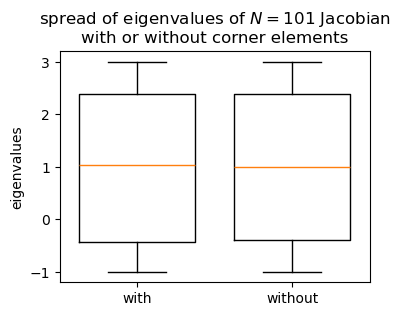

In [25]:
N = 101
# main diagonal
J = np.diag(np.ones(N, dtype=np.uint64))
# lower and upper diagonals
J += np.diag(np.ones(N-1, dtype=np.uint64), k=1)
J += np.diag(np.ones(N-1, dtype=np.uint64), k=-1)
J_nonperiodic = J.copy()
# corner elements
J[0, N-1] = 1
J[N-1, 0] = 1

# calculate eigenvalues
eigvals = np.linalg.eigvals(J)
eigvals_nonperiodic= np.linalg.eigvals(J_nonperiodic)

fig, ax = plt.subplots(1,1,figsize=(4,3))
ax.boxplot([eigvals, eigvals_nonperiodic], widths=.75)
ax.set_xticklabels(['with', 'without'])
ax.set_ylabel(f"eigenvalues")
ax.set_title(f"spread of eigenvalues of $N={N}$ Jacobian\nwith or without corner elements")

*Note* that the corner elements (which support the periodicity of the CA) have an important impact on the spread of the eigenvalues! In their absence, the spread of the eigenvalues is independent of the matrix size. Otherwise, it asymptotically approaches that spread for $N \rightarrow \infty$.

Now, from these eigenvalues we should be able to find the Lyapunov spectrum. Let us try it slightly different than with our previous definitions - now using Wikipedia. Let us define the matrix
$$
\Lambda = \lim_{t\rightarrow\infty}\frac{1}{2t}\ln\left(\mathbf{Y}(t)\mathbf{Y}(t)^T\right) = \lim_{t\rightarrow\infty}\frac{1}{2t}\ln\left(\mathbf{\Gamma}\right),
$$
where the natural logarithm is applied element-wise. Then the $N$ eigenvalues $\{\lambda_i\}$ of $\Lambda$ are precisely the Lyapunov exponents. Note two things:
1. There are certainly $N$ real-valued eigenvalues, because $\mathbf{\Gamma}$ is symmetric and real-valued.
2. The limit only exists because of the Oseledet's theorem (**QUESTION** not sure what this is).
3. **Problem** some elements in $\Gamma$ may be zero, so the element-wise logarithm works out to minus infinity, which is problematic when calculating the eigenvalues.
4. **Problem** the order of operations is important, of course! First applying the logarithm, or first finding the eigenvalues makes a big difference. Both definitions are used in Milan's paper, but I don't think that makes a whole lot of sense. in the code he uses the definition where first the eigenvalues are calculated (makes more sense I guess?).
5. ...

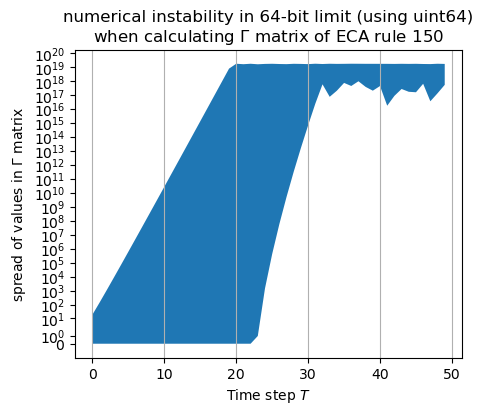

In [43]:
Gamma_mins = []
Gamma_maxs = []
Ts = np.arange(0, 50)
J_t = J.copy()
for T in Ts:
    print(T, end='\r')
    # NOTE this becomes expensive for high values of N
    J_t = np.matmul(J, J_t)
    Gamma = np.matmul(J_t, J_t.T)
    Gamma_min = np.min(Gamma)
    Gamma_max = np.max(Gamma)
    Gamma_maxs += [Gamma_max]
    Gamma_mins += [Gamma_min]

fig, ax = plt.subplots(1,1,figsize=(5,4))

ax.fill_between(Ts, Gamma_mins, Gamma_maxs)
# plt.plot(Ts, Gamma_mins)
ax.set_yscale('symlog')
ax.set_title("numerical instability in 64-bit limit (using uint64)\nwhen calculating $\\Gamma$ matrix of ECA rule 150")
# plt.ylabel("minimum value in $\\Gamma$ matrix")
ax.set_ylabel("spread of values in $\\Gamma$ matrix")
ax.set_xlabel("Time step $T$")
ax.xaxis.grid()

Clearly there is numerical instability after about 20 time steps, so this **will have to be addressed!** One way would be to make use of the `mpmath` Python package.

In [63]:
J.dot(J) == np.linalg.matrix_power(J, 2)

array([[ True,  True,  True, ...,  True,  True,  True],
       [ True,  True,  True, ...,  True,  True,  True],
       [ True,  True,  True, ...,  True,  True,  True],
       ...,
       [ True,  True,  True, ...,  True,  True,  True],
       [ True,  True,  True, ...,  True,  True,  True],
       [ True,  True,  True, ...,  True,  True,  True]])

In [67]:
# current max T value before numerical breakdown is 20 (but that is dependent on set-up)
T = 4
J_t = np.linalg.matrix_power(J, T)
Gamma = np.matmul(J_t, J_t.T)

print(np.max(Gamma))

Lambdas = np.log(Gamma)/(2*T)
lambdas, = np.linalg.eig(Lambdas)

_=plt.hist(lambdas, bins=100)

1107


C:\Users\mrollier\AppData\Local\Temp\ipykernel_9800\2149084753.py:8: RuntimeWarning: divide by zero encountered in log
  Lambdas = np.log(Gamma)/(2*T)


LinAlgError: Array must not contain infs or NaNs

## Milan's code

In [ ]:
### This file is made by Milan Vispoel

# %% imports

import networkx as nx
import matplotlib.pyplot as plt
import random
import numpy as np
from numpy import linalg as LA

def matrix_j(rule, parameters):
    #compute the product of Jacobians
    graph = nx.connected_watts_strogatz_graph(nodes, k, p_rewire, tries = 100, seed=None)
    states = cellular_automaton(graph, rule_90_150, parameters, ts)
    jac = jacobian(states[0], rule, parameters, graph)
    for t in range(1,ts):
        # NOTE: why is this states[ts]? According to equation (9) it should be states[t]
        jac = jacobian(states[ts], rule, parameters, graph).dot(jac)
    return jac

def lyapunov(rule, parameters):
    y_mat = matrix_j(rule, parameters)
    # NOTE: so here we first take the eigenvalues, and only take their logarithm afterwards
    w, v = LA.eig(y_mat*y_mat.T)
    return w

def lyapunov_average(rule, parameters, iterations):
    #compute the spectrum over a number of iterations to get statistically relevant results
    result = []
    for i in range(iterations):
        temp = lyapunov(rule, parameters)
        result.append(abs(temp))
        print(i)
    return result

def remove_z(arr):
    return arr[arr != 0]

# %% Executions and plot

eigenvalues = lyapunov_average(rule_90_150, parameters, iterations)
eigenvalues = np.sort((np.array(eigenvalues)).flatten())
# NOTE: why are we sure there are no negative eigenvalues?
spectrum = (1/(2*ts))*np.log(remove_z(eigenvalues))


#Plot spectrum in histogram
bin_count=50
normalized = False

if len(spectrum) > 0:
    plt.rcParams["figure.figsize"] = (12,8)
    plt.rcParams.update({'font.size': 20})
    N, bins, patches = plt.hist(spectrum, bins=bin_count, density=True, alpha=0.5, histtype='bar', ec='black')
    if normalized == True:
        plt.xlim(0,1)
    plt.xlabel("$\lambda$")
    plt.ylabel(r"$\rho(\lambda)$")
    plt.show()
# %%
